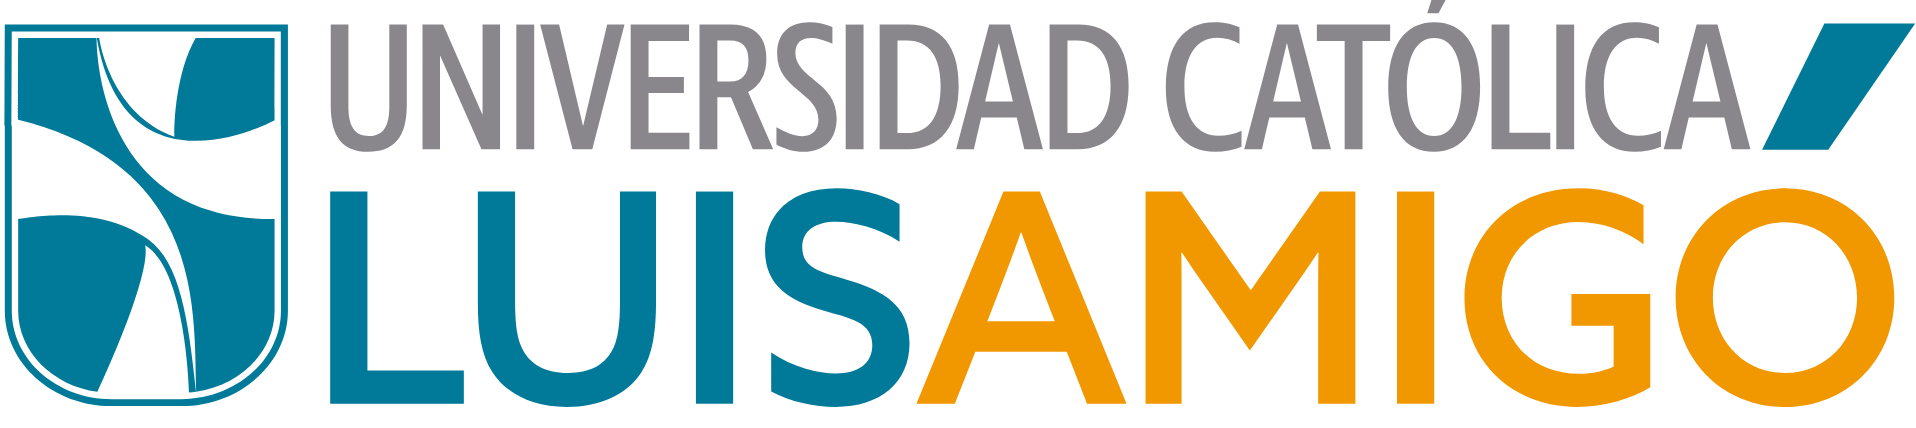

# Dataset: Perfil de morbilidad de la ESE Metrosalud

Esta BD detalla los diagnóstico de las atenciones a los pacientes de Metrosalud hasta el 26 de agosto de 2025

**Información de la Entidad**


| | |
|:-----------------------------|:---------------------------------------------------------------|
| Departamento | Antioquia  |
| Municipio	| Medellín |
| Nombre de la Entidad | Metrosalud |
| Orden	| Territorial |
| Área o dependencia | Comunicaciones |
| Sector | Salud y Protección Social |


**Información de Datos**


| | |
|:-----------------------------|:---------------------------------------------------------------|
| Idioma | Español  |
| Cobertura Geográfica | Municipal |
| Frecuencia de Actualización | Anual |


**Temas**


| | |
|:-----------------------------|:---------------------------------------------------------------|
| Categoría | Salud y Protección Social  |
| Etiquetas | Este conjunto de datos no tiene ninguna etiqueta |
| Frecuencia de Actualización | Anual |


**Suministró los datos**

Metrosalud

**Propietario de conjunto de datos**

Metrosalud

## Estructura del conjunto de datos

Este dataset extraido de *Datos abiertos* (nombrado: **Perfil de morbilidad de la ESE Metrosalud.csv** ) contiene información sobre **los diagnostico de las atenciones a los pacientes de Metrosalud**, los cuales serán usados para la predicción de un proceso de clasificación/caracterizacion ...

A continuación una breve descripción de las variables:

| Nombre de la variable                     | Descripción                                                   | Tipo de dato |
|:-----------------------------|:---------------------------------------------------------------|:---------|
| centro_de_costos | Código centro de costos  | floats |
| nombre_centro_de_costo | Nombre del centro de costos | strings |
| nombre_upss | Nombre de la microred | strings |
| unidad_funcional | Codigo unidad funcional | strings |
| nombre_unidad_funcional | Nombre de la unidad funcional | strings |
| fecha | Fecha de la atención | date |
| a_o_mes | Año mes de la atención | strings |
| fecha_nacimiento | Fecha de nacimiento | date |
| edad | Edad calculada hasta la fecha de atención | floats |
| unidad_edad | Unidad edad (dias,mes,año) | strings |
| edad_cie | Grupo de edad CIE | strings |
| edad_sivigila | Grupo de edad Sivigila | strings |
| edad_eda | Grupo de edad enfermedad diarreica aguda | strings |
| edad_ira | Grupo de edad enfermedad respiratoria aguda | strings |
| prescripcion | Tiene orden de medicamento (s/n) | strings |
| diagnosticos | Diagnóstico (s/n) | strings |
| terapeuticas | Terapeutico (s/n) | strings |
| frinterconsulta | Interconsulta (s/n) | strings |
| frcontrol | Enfermedad de control (s/n) | strings |
| embarazada | Embarazada (s/n) | strings |
| sexo | Sexo | strings |
| codigo_gestacion | Código gestación | strings |
| mes_gestacion | Mes de gestación | strings |
| dmovimiento | Fecha de la transacción | date |
| semana_epidemiologica | Semana Epidemiologica | strings |
| codigo_barrio_residencia | Código clasificación barrio | strings |
| nombre_barrio_residencia | Nombre barrio | strings |
| latitud_barrio | Código latitud barrio (georeferencia) | strings |
| longitud_barrio | Código longitud barrio (georeferencia) | strings |
| comuna | Nombre comuna Medellín | strings |
| entidad_aseguradora | Nombre entidad aseguradora | strings |
| codigo_especialidad | Código especialidad | strings |
| nombre_especialidad | Nombre especialidad atendió | strings |
| codigo_diagnostico_principal | Código CIE10 | strings |
| nombre_diagnostico_principal | Nombre diagnóstico | strings |
| tipo_diagnostico | Tipo de diagnóstico | strings |
| cie10_r1 | Código CIE10 | strings |
| nombre_diagnostico_r1 | Nombre diagnóstico | strings |
| cie10_r2 | Código CIE10 | strings |
| nombre_diagnostico_r2 | Nombre diagnóstico | strings |
| cie10_r3 | Codigo CIE10 | strings |
| nombre_diagnostico_r3 | Nombre diagnóstico | strings |
| vnomurgencia | Tipo de urgencia | strings |
| cantidad | Cantidad | floats |



**Fuente:** https://www.datos.gov.co/Salud-y-Protecci-n-Social/Perfil-de-morbilidad-de-la-ESE-Metrosalud/pypc-7h3w/about_data

In [ ]:
# Importar drive para cargar el archivo
# ==============================================================================
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Importar librerias

In [ ]:
# Tratamiento de datos
# ==============================================================================
import pandas as pd
import numpy as np

# Gráficos
# ==============================================================================
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns


# Preprocesado y modelado
# ==============================================================================
from sklearn.cluster import KMeans
from sklearn.preprocessing import scale

from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram


from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.metrics import pairwise_distances_argmin_min

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

from imblearn.over_sampling import RandomOverSampler

# Operaciones matemáticas o estadíticas
import math


# Configuración matplotlib
# ==============================================================================
plt.rcParams['image.cmap'] = "bwr"
#plt.rcParams['figure.dpi'] = "100"
plt.rcParams['savefig.bbox'] = "tight"
style.use('ggplot') or plt.style.use('ggplot')


# Configuración warnings
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')

## 2. Cargar dataset

In [ ]:
# Importamos el df desde el drive y realizamos delimitacion de datos por punto y coma (;)
d=pd.read_csv('/content/drive/MyDrive/TRABAJO GRADOS/Perfil_de_morbilidad_de_la_ESE_Metrosalud_20250903_sep.csv', sep=';')
#df_grafica=pd.read_csv('/content/drive/MyDrive/TRABAJO GRADOS/Perfil_de_morbilidad_de_la_ESE_Metrosalud_20250903_sep.csv', sep=';')

In [ ]:
# Importamos el df desde el drive y realizamos delimitacion de datos por punto y coma (;)
#d=pd.read_csv('/content/drive/MyDrive/1 trabajo grado/Perfil_de_morbilidad_de_la_ESE_Metrosalud_20251007.csv', sep=';')
#df_grafica=pd.read_csv('/content/drive/MyDrive/1 trabajo grado/Perfil_de_morbilidad_de_la_ESE_Metrosalud_20251007.csv', sep=';')

In [ ]:
# Mostramos la estructura del df con los primeros 5 registros
d.head(5)

,CENTRO DE COSTOS,NOMBRE CENTRO DE COSTO,NOMBRE UPSS,UNIDAD FUNCIONAL,NOMBRE UNIDAD FUNCIONAL,FECHA,AÑO_MES,FECHA NACIMIENTO,EDAD,UNIDAD_EDAD,...,NOMBRE DIAGNOSTICO PRINCIPAL,TIPO DIAGNOSTICO,CIE10 R1,NOMBRE DIAGNOSTICO R1,CIE10 R2,NOMBRE DIAGNOSTICO R2,CIE10 R3,NOMBRE DIAGNOSTICO R3,VNOMURGENCIA,CANTIDAD
0,"1,080,810",Buenos Aires Ambul Consulta externa y proced,UPSS BUENOS AIRES,10.0,CONSULTA EXTERNA,2024 Feb 27 10:52:10 AM,2024-02,1979 Jun 23 12:00:00 AM,44,Años,...,"Tumefaccion, masa o prominencia intraabdominal...",Repetida,M255,Dolor en articulacion,H605,"Otitis externa aguda, no infecciosa",NaN,NaN,NaN,1
1,"1,082,512",CS SAN LORENZO Servicios Ambulatorios - Salud ...,UPSS BUENOS AIRES,12.0,SALUD ORAL,2024 Apr 15 07:44:30 AM,2024-04,1979 Jun 23 12:00:00 AM,44,Años,...,Pulpitis,Nueva,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2,"1,082,512",CS SAN LORENZO Servicios Ambulatorios - Salud ...,UPSS BUENOS AIRES,12.0,SALUD ORAL,2024 Apr 17 08:29:08 AM,2024-04,1979 Jun 23 12:00:00 AM,44,Años,...,Caries de la dentina,Nueva,K040,Pulpitis,K081,"Perdida de dientes debida a accidente, extracc...",K051,Gingivitis cronica,NaN,1
3,"1,303,001",Santa Cruz Urgen Consulta y Procedimientos,UPSS SANTA CRUZ,1.0,URGENCIAS,2024 Feb 04 03:36:32 PM,2024-02,1960 May 10 12:00:00 AM,63,Años,...,Gastroenteritis y colitis de origen no especif...,Imp.Dx,NaN,NaN,NaN,NaN,NaN,NaN,Moderada,1
4,"1,303,001",Santa Cruz Urgen Consulta y Procedimientos,UPSS SANTA CRUZ,1.0,URGENCIAS,2024 Aug 16 10:00:16 PM,2024-08,1960 May 10 12:00:00 AM,64,Años,...,Distension muscular,Nueva,I10X,Hipertension esencial (primaria),NaN,NaN,NaN,NaN,Leve,1


In [ ]:
# Proporciona un resumen conciso del DataFrame
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1140583 entries, 0 to 1140582
Data columns (total 44 columns):
 #   Column                        Non-Null Count    Dtype  
---  ------                        --------------    -----  
 0   CENTRO DE COSTOS              1140583 non-null  object 
 1   NOMBRE CENTRO DE COSTO        1140583 non-null  object 
 2   NOMBRE UPSS                   1140583 non-null  object 
 3   UNIDAD FUNCIONAL              1009989 non-null  float64
 4   NOMBRE UNIDAD FUNCIONAL       1140327 non-null  object 
 5   FECHA                         1140583 non-null  object 
 6   AÑO_MES                       1140583 non-null  object 
 7   FECHA NACIMIENTO              1140583 non-null  object 
 8   EDAD                          1140583 non-null  int64  
 9   UNIDAD_EDAD                   1140583 non-null  object 
 10  EDAD_CIE                      1140583 non-null  object 
 11  EDAD_SIVIGILA                 1140583 non-null  object 
 12  EDAD_EDA                    

## Creamos variable etapa de vida para categorizar los pacientes

## **Etapas del ciclo de vida en humanos**

**Primera infancia (0-5 años)**: Gran desarrollo cerebral y estimulación por el juego.

**Infancia (6-11 años):** Aprendizaje escolar, desarrollo de la motricidad y la identidad.

**Adolescencia (12-18 años):** Cambios hormonales, físicos y cognitivos, y mayor independencia.

**Juventud (18-26 años):** Mayor madurez emocional, independencia y definición de personalidad.

**Adultez (27-59 años):** Madurez, consolidación profesional y a menudo la formación de una familia.

**Persona mayor (60 años en adelante):** Vejez, con posibles deterioros físicos y de los sentidos.

In [ ]:
# Función para clasificar las etapas de vida
def clasificar_etapa_vida(row):
    edad = row['EDAD']
    unidad_edad = row['UNIDAD_EDAD']

    # Asegurarse de que la edad sea tratada como un número, manejar errores
    try:
        edad = float(edad)
    except ValueError:
        return 'No especificado' # Manejar casos donde la edad no es un número

    if unidad_edad == 'Años':
        if edad >= 0 and edad <= 5:
            return 'Primera infancia (0-5 años)'
        elif edad >= 6 and edad <= 11:
            return 'Infancia (6-11 años)'
        elif edad >= 12 and edad <= 18:
            return 'Adolescencia (12-18 años)'
        elif edad >= 19 and edad <= 26:
            return 'Juventud (19-26 años)'
        elif edad >= 27 and edad <= 59:
            return 'Adultez (27-59 años)'
        elif edad >= 60:
            return 'Persona mayor (60 años en adelante)'
    elif unidad_edad in ['Meses', 'Días'] and edad >= 0: # Incluir edad positiva en días o meses en Primera infancia
         return 'Primera infancia (0-5 años)'
    else: # Manejar valores inesperados de unidad_edad o edades negativas no cubiertas
        return 'No especificado'

# Crea la variable 'ETAPA_VIDA'
d['ETAPA_VIDA'] = d.apply(clasificar_etapa_vida, axis=1)

# Recuento de datos
display(d['ETAPA_VIDA'].value_counts())

,count
ETAPA_VIDA,
Adultez (27-59 años),399468
Persona mayor (60 años en adelante),389073
Juventud (19-26 años),144988
Primera infancia (0-5 años),87558
Adolescencia (12-18 años),74873
Infancia (6-11 años),44609
No especificado,14


In [ ]:
d.head(5)

,CENTRO DE COSTOS,NOMBRE CENTRO DE COSTO,NOMBRE UPSS,UNIDAD FUNCIONAL,NOMBRE UNIDAD FUNCIONAL,FECHA,AÑO_MES,FECHA NACIMIENTO,EDAD,UNIDAD_EDAD,...,TIPO DIAGNOSTICO,CIE10 R1,NOMBRE DIAGNOSTICO R1,CIE10 R2,NOMBRE DIAGNOSTICO R2,CIE10 R3,NOMBRE DIAGNOSTICO R3,VNOMURGENCIA,CANTIDAD,ETAPA_VIDA
0,"1,080,810",Buenos Aires Ambul Consulta externa y proced,UPSS BUENOS AIRES,10.0,CONSULTA EXTERNA,2024 Feb 27 10:52:10 AM,2024-02,1979 Jun 23 12:00:00 AM,44,Años,...,Repetida,M255,Dolor en articulacion,H605,"Otitis externa aguda, no infecciosa",NaN,NaN,NaN,1,Adultez (27-59 años)
1,"1,082,512",CS SAN LORENZO Servicios Ambulatorios - Salud ...,UPSS BUENOS AIRES,12.0,SALUD ORAL,2024 Apr 15 07:44:30 AM,2024-04,1979 Jun 23 12:00:00 AM,44,Años,...,Nueva,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Adultez (27-59 años)
2,"1,082,512",CS SAN LORENZO Servicios Ambulatorios - Salud ...,UPSS BUENOS AIRES,12.0,SALUD ORAL,2024 Apr 17 08:29:08 AM,2024-04,1979 Jun 23 12:00:00 AM,44,Años,...,Nueva,K040,Pulpitis,K081,"Perdida de dientes debida a accidente, extracc...",K051,Gingivitis cronica,NaN,1,Adultez (27-59 años)
3,"1,303,001",Santa Cruz Urgen Consulta y Procedimientos,UPSS SANTA CRUZ,1.0,URGENCIAS,2024 Feb 04 03:36:32 PM,2024-02,1960 May 10 12:00:00 AM,63,Años,...,Imp.Dx,NaN,NaN,NaN,NaN,NaN,NaN,Moderada,1,Persona mayor (60 años en adelante)
4,"1,303,001",Santa Cruz Urgen Consulta y Procedimientos,UPSS SANTA CRUZ,1.0,URGENCIAS,2024 Aug 16 10:00:16 PM,2024-08,1960 May 10 12:00:00 AM,64,Años,...,Nueva,I10X,Hipertension esencial (primaria),NaN,NaN,NaN,NaN,Leve,1,Persona mayor (60 años en adelante)


## Buscar enfermedades CIE10 según palabras 'tumor', 'vih', 'enfermedad renal cronica', 'hepatitis', 'hemofilia', 'artritis reumatoide'

In [ ]:
# Definir las palabras clave a buscar
keywords = ['tumor','vih', 'enfermedad renal cronica', 'hepatitis', 'hemofilia', 'artritis reumatoide']

# Función para buscar palabras clave en los nombres de diagnóstico y devolver los códigos y nombres correspondientes
def find_codes_by_keywords(df, keywords):
    found_diagnoses = {}
    # Columnas donde buscar las palabras clave
    name_columns = ['NOMBRE DIAGNOSTICO PRINCIPAL', 'NOMBRE DIAGNOSTICO R1', 'NOMBRE DIAGNOSTICO R2', 'NOMBRE DIAGNOSTICO R3']
    # Columnas de código correspondientes
    code_columns = ['CODIGO DIAGNOSTICO PRINCIPAL', 'CIE10 R1', 'CIE10 R2', 'CIE10 R3']

    for keyword in keywords:
        found_diagnoses[keyword] = set() # Usar un conjunto para evitar duplicados

        for name_col, code_col in zip(name_columns, code_columns):
            # Asegurarse de que la columna no sea nula antes de aplicar string methods
            if name_col in df.columns and code_col in df.columns:
                # Buscar filas donde el nombre del diagnóstico contiene la palabra clave (ignorando mayúsculas/minúsculas)
                # y donde el código de diagnóstico no es nulo o 0 (si ya se rellenaron nulos con 0)
                mask = df[name_col].str.contains(keyword, case=False, na=False) & df[code_col].notna()
                if df[code_col].dtype != 'object': # Si la columna de código es numérica (después de fillna(0))
                     mask = mask & (df[code_col] != 0)

                # Añadir los pares (código, nombre) encontrados al conjunto
                for code, name in zip(df.loc[mask, code_col], df.loc[mask, name_col]):
                    found_diagnoses[keyword].add((code, name))

    return found_diagnoses

# Buscar los códigos y nombres de diagnóstico relevantes en el DataFrame original (antes de eliminar columnas)
# Usaré df_grafica ya que parece que no se le eliminaron las columnas de nombre de diagnóstico
relevant_diagnoses = find_codes_by_keywords(d, keywords)

# Mostrar los resultados
print("Códigos CIE10 y nombres de diagnóstico relacionados con las palabras clave:")
for keyword, diagnoses in relevant_diagnoses.items():
    print(f"\nPalabra clave: '{keyword}'")
    if diagnoses:
        for code, name in diagnoses:
            print(f"  - Código: {code}, Nombre: {name}")
    else:
        print(f"  - No se encontraron diagnósticos para '{keyword}'.")

Códigos CIE10 y nombres de diagnóstico relacionados con las palabras clave:

Palabra clave: 'tumor'
  - Código: C260, Nombre: Tumor maligno del intestino, parte no especificada
  - Código: Z080, Nombre: Examen de seguimiento consecutivo a cirugia por tumor maligno
  - Código: C798, Nombre: Tumor maligno secundario de otros sitios especificados
  - Código: C740, Nombre: Tumor maligno de la corteza de la glandula suprarrenal
  - Código: C152, Nombre: Tumor maligno del esofago, porcion abdominal
  - Código: D486, Nombre: Tumor de comportamiento incierto o desconocido de la mama
  - Código: C091, Nombre: Tumor maligno del pilar amigdalino (anterior) (posterior)
  - Código: D413, Nombre: Tumor de comportamiento incierto o desconocido de la uretra
  - Código: C64X, Nombre: Tumor maligno del rinon, excepto de la pelvis renal
  - Código: C759, Nombre: Tumor maligno de glandula endocrina no especificada
  - Código: C01X, Nombre: Tumor maligno de la base de la lengua
  - Código: D287, Nombre: Tu

## Creación de diccionarios con código y nombre de diagnóstico

In [ ]:
# Crear un diccionario de mapeo de código a nombre de diagnóstico principal
diagnosticos_dict = d.set_index('CODIGO DIAGNOSTICO PRINCIPAL')['NOMBRE DIAGNOSTICO PRINCIPAL'].dropna().to_dict()

# Mostrar los elementos del diccionario
diagnosticos_dict

{'R190': 'Tumefaccion, masa o prominencia intraabdominal y pelvica',
 'K040': 'Pulpitis',
 'K021': 'Caries de la dentina',
 'A099': 'Gastroenteritis y colitis de origen no especificado',
 'M626': 'Distension muscular',
 'Y792': 'Dispositivos ortopedicos asociados con incidentes adversos, dispositivos protesicos y otros implantes, materiales y accesorios',
 'M796': 'Dolor en miembro',
 'R104': 'Otros dolores abdominales y los no especificados',
 'M546': 'Dolor en la columna dorsal',
 'R600': 'Edema localizado',
 'R220': 'Tumefaccion, masa o prominencia localizada en la cabeza',
 'R074': 'Dolor en el pecho, no especificado',
 'M549': 'Dorsalgia, no especificada',
 'M511': 'Trastornos de disco lumbar y otros, con radiculopatia',
 'J039': 'Amigdalitis aguda, no especificada',
 'E782': 'Hiperlipidemia mixta',
 'H110': 'Pterigion',
 'K083': 'Raiz dental retenida',
 'K589': 'Sindrome del colon irritable sin diarrea',
 'I10X': 'Hipertension esencial (primaria)',
 'A46X': 'Erisipela',
 'R32X': 

In [ ]:
# Crear un diccionario de mapeo de código a nombre de diagnóstico relacionado 1
diagnosticos_dict2 = d.set_index('CIE10 R1')['NOMBRE DIAGNOSTICO R1'].dropna().to_dict()

# Mostrar los elementos del diccionario
diagnosticos_dict2

{'M255': 'Dolor en articulacion',
 'K040': 'Pulpitis',
 'I10X': 'Hipertension esencial (primaria)',
 'S500': 'Contusion del codo',
 'F419': 'Trastorno de ansiedad, no especificado',
 'L500': 'Urticaria alergica',
 'M542': 'Cervicalgia',
 'E669': 'Obesidad, no especificada',
 'F329': 'Episodio depresivo, no especificado',
 'Z111': 'Examen de pesquisa especial para tuberculosis respiratoria',
 'E079': 'Trastorno de la glandula tiroides, no especificado',
 'N300': 'Cistitis aguda',
 'K582': 'SINDROME DE COLON IRRITABLE CON PREDOMINIO DE CONSTIPACION',
 'F412': 'Trastorno mixto de ansiedad y depresion',
 'K083': 'Raiz dental retenida',
 'A090': 'Otras gastroenteritis y colitis de origen infeccioso',
 'E785': 'Hiperlipidemia no especificada',
 'R55X': 'Sincope y colapso',
 'E119': 'Diabetes mellitus no insulinodependiente, sin mencion de complicacion',
 'K021': 'Caries de la dentina',
 'G470': 'Trastornos del inicio y del mantenimiento del sueno [insomnios]',
 'J449': 'Enfermedad pulmonar o

In [ ]:
# Crear un diccionario de mapeo de código a nombre de diagnóstico relacionado 2
diagnosticos_dict3 = d.set_index('CIE10 R2')['NOMBRE DIAGNOSTICO R2'].dropna().to_dict()

# Mostrar los elementos del diccionario
diagnosticos_dict3

{'H605': 'Otitis externa aguda, no infecciosa',
 'K081': 'Perdida de dientes debida a accidente, extraccion o enfermedad periodontal local',
 'M255': 'Dolor en articulacion',
 'F319': 'Trastorno afectivo bipolar, no especificado',
 'N760': 'Vaginitis aguda',
 'I872': 'Insuficiencia venosa (cronica) (periferica)',
 'E785': 'Hiperlipidemia no especificada',
 'K051': 'Gingivitis cronica',
 'B829': 'Parasitosis intestinal, sin otra especificacion',
 'M150': '(Osteo)artrosis primaria generalizada',
 'M154': '(Osteo)artrosis erosiva',
 'N182': 'Enfermedad renal crónica, etapa 2',
 'H269': 'Catarata, no especificada',
 'J449': 'Enfermedad pulmonar obstructiva cronica, no especificada',
 'E748': 'Otros trastornos especificados del metabolismo de los carbohidratos',
 'E669': 'Obesidad, no especificada',
 'F419': 'Trastorno de ansiedad, no especificado',
 'K036': 'Depositos [acreciones] en los dientes',
 'R030': 'Lectura elevada de la presion sanguinea, sin diagnostico de hipertension',
 'I839':

In [ ]:
# Crear un diccionario de mapeo de código a nombre de diagnóstico relacionado 3
diagnosticos_dict4 = d.set_index('CIE10 R3')['NOMBRE DIAGNOSTICO R3'].dropna().to_dict()

# Mostrar los elementos del diccionario
diagnosticos_dict4

{'K051': 'Gingivitis cronica',
 'R600': 'Edema localizado',
 'M239': 'Trastorno interno de la rodilla, no especificado',
 'G470': 'Trastornos del inicio y del mantenimiento del sueno [insomnios]',
 'E669': 'Obesidad, no especificada',
 'K036': 'Depositos [acreciones] en los dientes',
 'J449': 'Enfermedad pulmonar obstructiva cronica, no especificada',
 'M659': 'Sinovitis y tenosinovitis, no especificada',
 'M179': 'Gonartrosis, no especificada',
 'M199': 'Artrosis, no especificada',
 'K291': 'Otras gastritis agudas',
 'K081': 'Perdida de dientes debida a accidente, extraccion o enfermedad periodontal local',
 'I429': 'Cardiomiopatia, no especificada',
 'I10X': 'Hipertension esencial (primaria)',
 'F419': 'Trastorno de ansiedad, no especificado',
 'R943': 'Resultados anormales en estudios funcionales cardiovasculares',
 'I451': 'Otros tipos de bloqueo de rama derecha del haz y los no especificados',
 'M255': 'Dolor en articulacion',
 'E078': 'Otros trastornos especificados de la glandul

## 3. Limpieza de datos

In [ ]:
#Borrando columnas innecesarias
d.drop([ 'NOMBRE BARRIO RESIDENCIA', 'NOMBRE CENTRO DE COSTO', 'COMUNA', 'NOMBRE_ESPECIALIDAD','CODIGO GESTACION', 'NOMBRE DIAGNOSTICO R1',
        'NOMBRE DIAGNOSTICO R2', 'NOMBRE DIAGNOSTICO R3', 'SEMANA EPIDEMIOLOGICA', 'EDAD_CIE', 'EDAD_SIVIGILA', 'EDAD_EDA', 'EDAD_IRA',
         'LATITUD BARRIO', 'LONGITUD BARRIO', 'FECHA NACIMIENTO'], axis='columns', inplace=True)

In [ ]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1140583 entries, 0 to 1140582
Data columns (total 29 columns):
 #   Column                        Non-Null Count    Dtype  
---  ------                        --------------    -----  
 0   CENTRO DE COSTOS              1140583 non-null  object 
 1   NOMBRE UPSS                   1140583 non-null  object 
 2   UNIDAD FUNCIONAL              1009989 non-null  float64
 3   NOMBRE UNIDAD FUNCIONAL       1140327 non-null  object 
 4   FECHA                         1140583 non-null  object 
 5   AÑO_MES                       1140583 non-null  object 
 6   EDAD                          1140583 non-null  int64  
 7   UNIDAD_EDAD                   1140583 non-null  object 
 8   PRESCRIPCION                  1140583 non-null  object 
 9   DIAGNOSTICOS                  1140583 non-null  object 
 10  TERAPEUTICAS                  1140583 non-null  object 
 11  FRINTERCONSULTA               1140583 non-null  object 
 12  FRCONTROL                   

In [ ]:
d.head(10)

,CENTRO DE COSTOS,NOMBRE UPSS,UNIDAD FUNCIONAL,NOMBRE UNIDAD FUNCIONAL,FECHA,AÑO_MES,EDAD,UNIDAD_EDAD,PRESCRIPCION,DIAGNOSTICOS,...,CODIGO ESPECIALIDAD,CODIGO DIAGNOSTICO PRINCIPAL,NOMBRE DIAGNOSTICO PRINCIPAL,TIPO DIAGNOSTICO,CIE10 R1,CIE10 R2,CIE10 R3,VNOMURGENCIA,CANTIDAD,ETAPA_VIDA
0,"1,080,810",UPSS BUENOS AIRES,10.0,CONSULTA EXTERNA,2024 Feb 27 10:52:10 AM,2024-02,44,Años,Si,No,...,1.0,R190,"Tumefaccion, masa o prominencia intraabdominal...",Repetida,M255,H605,NaN,NaN,1,Adultez (27-59 años)
1,"1,082,512",UPSS BUENOS AIRES,12.0,SALUD ORAL,2024 Apr 15 07:44:30 AM,2024-04,44,Años,Si,No,...,2.0,K040,Pulpitis,Nueva,NaN,NaN,NaN,NaN,1,Adultez (27-59 años)
2,"1,082,512",UPSS BUENOS AIRES,12.0,SALUD ORAL,2024 Apr 17 08:29:08 AM,2024-04,44,Años,No,No,...,2.0,K021,Caries de la dentina,Nueva,K040,K081,K051,NaN,1,Adultez (27-59 años)
3,"1,303,001",UPSS SANTA CRUZ,1.0,URGENCIAS,2024 Feb 04 03:36:32 PM,2024-02,63,Años,No,No,...,1.0,A099,Gastroenteritis y colitis de origen no especif...,Imp.Dx,NaN,NaN,NaN,Moderada,1,Persona mayor (60 años en adelante)
4,"1,303,001",UPSS SANTA CRUZ,1.0,URGENCIAS,2024 Aug 16 10:00:16 PM,2024-08,64,Años,No,No,...,1.0,M626,Distension muscular,Nueva,I10X,NaN,NaN,Leve,1,Persona mayor (60 años en adelante)
5,"1,303,001",UPSS SANTA CRUZ,1.0,URGENCIAS,2024 Oct 23 11:02:39 AM,2024-10,64,Años,No,No,...,1.0,Y792,Dispositivos ortopedicos asociados con inciden...,Repetida,S500,M255,R600,Moderada,1,Persona mayor (60 años en adelante)
6,"1,303,001",UPSS SANTA CRUZ,1.0,URGENCIAS,2024 Oct 22 07:34:40 PM,2024-10,64,Años,No,No,...,1.0,M796,Dolor en miembro,Nueva,F419,NaN,NaN,Moderada,1,Persona mayor (60 años en adelante)
7,"1,183,410",UPSS CASTILLA,10.0,CONSULTA EXTERNA,2024 Sep 24 06:22:03 AM,2024-09,64,Años,Si,No,...,1.0,R104,Otros dolores abdominales y los no especificados,Repetida,NaN,NaN,NaN,NaN,1,Persona mayor (60 años en adelante)
8,"1,303,001",UPSS SANTA CRUZ,1.0,URGENCIAS,2024 Dec 26 05:20:16 PM,2024-12,64,Años,No,No,...,1.0,M546,Dolor en la columna dorsal,Imp.Dx,NaN,NaN,NaN,Moderada,1,Persona mayor (60 años en adelante)
9,"1,303,001",UPSS SANTA CRUZ,1.0,URGENCIAS,2024 Oct 21 11:33:45 AM,2024-10,45,Años,No,No,...,1.0,R600,Edema localizado,Imp.Dx,L500,NaN,NaN,Moderada,1,Adultez (27-59 años)


In [ ]:
# Convertir las columnas de fecha a objetos datetime
d['DMOVIMIENTO'] = pd.to_datetime(d['DMOVIMIENTO'])
d['FECHA'] = pd.to_datetime(d['FECHA'])

d['AÑO_MES'] = pd.to_datetime(d['AÑO_MES'])
d['FECHA'] = pd.to_datetime(d['FECHA'])

# Mostrar los tipos de datos para confirmar el cambio
display(d.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1140583 entries, 0 to 1140582
Data columns (total 29 columns):
 #   Column                        Non-Null Count    Dtype         
---  ------                        --------------    -----         
 0   CENTRO DE COSTOS              1140583 non-null  object        
 1   NOMBRE UPSS                   1140583 non-null  object        
 2   UNIDAD FUNCIONAL              1009989 non-null  float64       
 3   NOMBRE UNIDAD FUNCIONAL       1140327 non-null  object        
 4   FECHA                         1140583 non-null  datetime64[ns]
 5   AÑO_MES                       1140583 non-null  datetime64[ns]
 6   EDAD                          1140583 non-null  int64         
 7   UNIDAD_EDAD                   1140583 non-null  object        
 8   PRESCRIPCION                  1140583 non-null  object        
 9   DIAGNOSTICOS                  1140583 non-null  object        
 10  TERAPEUTICAS                  1140583 non-null  object        
 11

None

## Transformación númerica

In [ ]:
# Convertir la columna 'PRESCRIPCION' a numérica (1 para 'Si', 0 para 'No')
d['PRESCRIPCION'] = d['PRESCRIPCION'].apply(lambda x: 1 if x == 'Si' else 0)

# Mostrar el conteo de valores para confirmar el cambio
display(d['PRESCRIPCION'].value_counts())

,count
PRESCRIPCION,
1,582467
0,558116


In [ ]:
# Convertir la columna 'DIAGNOSTICOS' a numérica (1 para 'Si', 0 para 'No')
d['DIAGNOSTICOS'] = d['DIAGNOSTICOS'].apply(lambda x: 1 if x == 'Si' else 0)

# Mostrar el conteo de valores para confirmar el cambio
display(d['DIAGNOSTICOS'].value_counts())

,count
DIAGNOSTICOS,
0,816683
1,323900


In [ ]:
# Rellenar los valores nulos en las columnas CIE10 R1, CIE10 R2 y CIE10 R3 con 0
columns_to_fill = ['CIE10 R1', 'CIE10 R2', 'CIE10 R3']
d[columns_to_fill] = d[columns_to_fill].fillna(0)


In [ ]:
# Crear variables dummy para la columna 'TIPO DIAGNOSTICO'
tipo_diagnostico_dummies = pd.get_dummies(d['TIPO DIAGNOSTICO'], prefix='TIPO_DIAGNOSTICO')

# Concatenar las nuevas columnas dummy con el DataFrame original
d = pd.concat([d, tipo_diagnostico_dummies], axis=1)

In [ ]:
# Crear variables dummy para la columna 'VNOMURGENCIA'
vnomurgencia_dummies = pd.get_dummies(d['VNOMURGENCIA'], prefix='VNOMURGENCIA')

# Concatenar las nuevas columnas dummy con el DataFrame original
d = pd.concat([d, vnomurgencia_dummies], axis=1)

In [ ]:
# Rellenar los valores nulos en la columna 'MES GESTACION' con 'No Aplica'
d['MES GESTACION'] = d['MES GESTACION'].fillna('No Aplica')

# Crear variables dummy para la columna 'MES GESTACION'
mes_gestacion_dummies = pd.get_dummies(d['MES GESTACION'], prefix='MES_GESTACION')

# Concatenar las nuevas columnas dummy con el DataFrame original
d = pd.concat([d, mes_gestacion_dummies], axis=1)

## Se borran despues de dummies porque se vuelven innecesarias para el modelo


In [ ]:
# Eliminar columnas innecesarias
d.drop([ 'VNOMURGENCIA','TIPO DIAGNOSTICO','NOMBRE DIAGNOSTICO PRINCIPAL','NOMBRE UNIDAD FUNCIONAL','MES GESTACION','CENTRO DE COSTOS'], axis='columns', inplace=True)

## Continuamos con transformación de datos

In [ ]:
# Convertir la columna 'TERAPEUTICAS' a numérica (1 para 'Si', 0 para 'No')
d['TERAPEUTICAS'] = d['TERAPEUTICAS'].apply(lambda x: 1 if x == 'Si' else 0)

# Mostrar el conteo de valores para confirmar el cambio
display(d['TERAPEUTICAS'].value_counts())

,count
TERAPEUTICAS,
0,1140583


In [ ]:
# Convertir la columna 'FRINTERCONSULTA' a numérica (1 para 'Si', 0 para 'No')
d['FRINTERCONSULTA'] = d['FRINTERCONSULTA'].apply(lambda x: 1 if x == 'Si' else 0)

# Mostrar el conteo de valores para confirmar el cambio
display(d['FRINTERCONSULTA'].value_counts())

,count
FRINTERCONSULTA,
0,1140582
1,1


In [ ]:
# Convertir la columna 'FRCONTROL' a numérica (1 para 'Si', 0 para 'No')
d['FRCONTROL'] = d['FRCONTROL'].apply(lambda x: 1 if x == 'Si' else 0)

# Mostrar el conteo de valores para confirmar el cambio
display(d['FRCONTROL'].value_counts())

,count
FRCONTROL,
0,1130743
1,9840


In [ ]:
# Reemplazar 'S' por 1 y 'N' por 0 en la columna 'EMBARAZADA'
d['EMBARAZADA'] = d['EMBARAZADA'].replace({'S': 1, 'N': 0})

# Mostrar el conteo de valores para confirmar el cambio
display(d['EMBARAZADA'].value_counts())

,count
EMBARAZADA,
0,1100995
1,39588


In [ ]:
"""# Rellenar los valores nulos en la columna 'CODIGO GESTACION' con 0
d['CODIGO GESTACION'] = d['CODIGO GESTACION'].fillna(0)

# Mostrar el conteo de valores para confirmar el cambio
display(d['CODIGO GESTACION'].value_counts())"""

KeyError: 'CODIGO GESTACION'

In [ ]:
# Eliminar filas donde 'SEXO' es 'Indefinido'
d = d[d['SEXO'] != 'Indefinido'].copy()

# Mostrar el conteo de valores para confirmar el cambio
display(d['SEXO'].value_counts())

,count
SEXO,
Femenino,748033
Masculino,392447


In [ ]:
# Reemplazar 'Masculino' por 1 y 'Femenino' por 0 en la columna 'SEXO'
d['SEXO'] = d['SEXO'].replace({'Masculino': 1, 'Femenino': 0}).astype(int)

# Mostrar el conteo de valores y el tipo de dato para confirmar el cambio
display(d['SEXO'].value_counts())
display(d['SEXO'].dtype)

,count
SEXO,
0,748033
1,392447


dtype('int64')

In [ ]:
# Lista de columnas booleanas para convertir
boolean_cols = [
    'TIPO_DIAGNOSTICO_Imp.Dx', 'TIPO_DIAGNOSTICO_Nueva', 'TIPO_DIAGNOSTICO_Repetida',
    'VNOMURGENCIA_Grave', 'VNOMURGENCIA_Leve', 'VNOMURGENCIA_Moderada',
    'VNOMURGENCIA_Muy grave', 'VNOMURGENCIA_No Urgente','MES_GESTACION_Primer trimestre','MES_GESTACION_Segundo Trimestre','MES_GESTACION_No Aplica','MES_GESTACION_Tercer Trimestre'
]

# Convertir columnas booleanas a entero (True se convierte en 1, False se convierte en 0)
d[boolean_cols] = d[boolean_cols].astype(int)

In [ ]:
d.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1140480 entries, 0 to 1140582
Data columns (total 35 columns):
 #   Column                           Non-Null Count    Dtype         
---  ------                           --------------    -----         
 0   NOMBRE UPSS                      1140480 non-null  object        
 1   UNIDAD FUNCIONAL                 1009908 non-null  float64       
 2   FECHA                            1140480 non-null  datetime64[ns]
 3   AÑO_MES                          1140480 non-null  datetime64[ns]
 4   EDAD                             1140480 non-null  int64         
 5   UNIDAD_EDAD                      1140480 non-null  object        
 6   PRESCRIPCION                     1140480 non-null  int64         
 7   DIAGNOSTICOS                     1140480 non-null  int64         
 8   TERAPEUTICAS                     1140480 non-null  int64         
 9   FRINTERCONSULTA                  1140480 non-null  int64         
 10  FRCONTROL                        11

In [ ]:
d.head()

,NOMBRE UPSS,UNIDAD FUNCIONAL,FECHA,AÑO_MES,EDAD,UNIDAD_EDAD,PRESCRIPCION,DIAGNOSTICOS,TERAPEUTICAS,FRINTERCONSULTA,...,TIPO_DIAGNOSTICO_Repetida,VNOMURGENCIA_Grave,VNOMURGENCIA_Leve,VNOMURGENCIA_Moderada,VNOMURGENCIA_Muy grave,VNOMURGENCIA_No Urgente,MES_GESTACION_No Aplica,MES_GESTACION_Primer trimestre,MES_GESTACION_Segundo Trimestre,MES_GESTACION_Tercer Trimestre
0,UPSS BUENOS AIRES,10.0,2024-02-27 10:52:10,2024-02-01,44,Años,1,0,0,0,...,1,0,0,0,0,0,1,0,0,0
1,UPSS BUENOS AIRES,12.0,2024-04-15 07:44:30,2024-04-01,44,Años,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,UPSS BUENOS AIRES,12.0,2024-04-17 08:29:08,2024-04-01,44,Años,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
3,UPSS SANTA CRUZ,1.0,2024-02-04 15:36:32,2024-02-01,63,Años,0,0,0,0,...,0,0,0,1,0,0,1,0,0,0
4,UPSS SANTA CRUZ,1.0,2024-08-16 22:00:16,2024-08-01,64,Años,0,0,0,0,...,0,0,1,0,0,0,1,0,0,0


## Balanceo

In [ ]:
# Obtener los códigos CIE10 relevantes de la ejecución anterior
relevant_codes = set()
for keyword, diagnoses in relevant_diagnoses.items():
    for code, name in diagnoses:
        relevant_codes.add(code)

# Crear la columna objetivo 'Alto_Costo'
diagnosis_cols = ['CODIGO DIAGNOSTICO PRINCIPAL', 'CIE10 R1', 'CIE10 R2', 'CIE10 R3']
d['Alto_Costo'] = d.apply(lambda row: 1 if any(str(row[col]) in relevant_codes for col in diagnosis_cols) else 0, axis=1)

# Preparar características y objetivo
X = d.select_dtypes(include=np.number).drop('Alto_Costo', axis=1)
y = d['Alto_Costo']  # Objetivo

# Manejar posibles valores faltantes en las características numéricas seleccionadas (imputación simple con la media)
X = X.fillna(X.mean())

# Verificar si la variable objetivo tiene más de una clase antes de aplicar RandomOverSampler
if y.nunique() <= 1:
    print("Error: La variable objetivo 'Alto_Costo' tiene solo una clase.")
    print("Por favor, verifica la lista de palabras clave o los datos para asegurarte de que hay diagnósticos de alto costo presentes.")
else:
    # Aplicar RandomOverSampler
    ros = RandomOverSampler(random_state=42)
    X_resampled, y_resampled = ros.fit_resample(X, y)

    print("Balanceo de datos completo usando RandomOverSampler.")
    print(f"Forma original de las características numéricas: {X.shape}, forma del objetivo: {y.shape}")
    print(f"Forma del conjunto de datos remuestreado: {X_resampled.shape}, {y_resampled.shape}")

    # Mostrar el conteo de valores de la variable objetivo remuestreada para mostrar el balanceo
    print("\nConteo de valores de la variable objetivo después del sobremuestreo:")
    print(pd.Series(y_resampled).value_counts())

Balanceo de datos completo usando RandomOverSampler.
Forma original de las características numéricas: (1140480, 24), forma del objetivo: (1140480,)
Forma del conjunto de datos remuestreado: (2180414, 24), (2180414,)

Conteo de valores de la variable objetivo después del sobremuestreo:
Alto_Costo
0    1090207
1    1090207
Name: count, dtype: int64


In [ ]:
d.head(5)


,NOMBRE UPSS,UNIDAD FUNCIONAL,FECHA,AÑO_MES,EDAD,UNIDAD_EDAD,PRESCRIPCION,DIAGNOSTICOS,TERAPEUTICAS,FRINTERCONSULTA,...,VNOMURGENCIA_Grave,VNOMURGENCIA_Leve,VNOMURGENCIA_Moderada,VNOMURGENCIA_Muy grave,VNOMURGENCIA_No Urgente,MES_GESTACION_No Aplica,MES_GESTACION_Primer trimestre,MES_GESTACION_Segundo Trimestre,MES_GESTACION_Tercer Trimestre,Alto_Costo
0,UPSS BUENOS AIRES,10.0,2024-02-27 10:52:10,2024-02-01,44,Años,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,UPSS BUENOS AIRES,12.0,2024-04-15 07:44:30,2024-04-01,44,Años,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,UPSS BUENOS AIRES,12.0,2024-04-17 08:29:08,2024-04-01,44,Años,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,UPSS SANTA CRUZ,1.0,2024-02-04 15:36:32,2024-02-01,63,Años,0,0,0,0,...,0,0,1,0,0,1,0,0,0,0
4,UPSS SANTA CRUZ,1.0,2024-08-16 22:00:16,2024-08-01,64,Años,0,0,0,0,...,0,1,0,0,0,1,0,0,0,0


In [ ]:
"""# Balanceo de datos
# ==============================================================================
from imblearn.over_sampling import RandomOverSampler
import pandas as pd
import numpy as np

# Define una lista de ejemplo de códigos de enfermedades de alto costo.
# IMPORTANTE: Reemplaza estos con los códigos reales que representan enfermedades de alto costo en tu conjunto de datos.
high_cost_diseases = ['I10X', 'E119', 'J441', 'N390', 'E109', 'J449', 'N40X', 'I500', 'Z123', 'J189', 'I251', 'E785', 'M255', 'K040', 'K021', 'A099'] #--> se comenta para probar
#high_cost_diseases = ['tumor','vih', 'enfermedad renal cronica', 'hepatitis', 'hemofilia', 'artritis reumatoide']
#relevant_diagnoses = ['tumor','vih', 'enfermedad renal cronica', 'hepatitis', 'hemofilia', 'artritis reumatoide']

# Asegúrate de que la columna objetivo 'Alto_Costo' exista. Si no, intenta crearla a partir de high_cost_diseases si está disponible.
if 'Alto_Costo' not in d.columns:
        if 'high_cost_diseases' in globals():
                # asegúrate de que la columna de códigos de diagnóstico exista
                if 'CODIGO DIAGNOSTICO PRINCIPAL' in d.columns:
                        d['CODIGO DIAGNOSTICO PRINCIPAL'] = d['CODIGO DIAGNOSTICO PRINCIPAL'].fillna('').astype(str)
                        d['Alto_Costo'] = d['CODIGO DIAGNOSTICO PRINCIPAL'].apply(lambda x: 1 if x in high_cost_diseases else 0)
                        print("Columna 'Alto_Costo' creada a partir de 'high_cost_diseases'.")
                else:
                        # alternativa: crear todo ceros y advertir al usuario
                        d['Alto_Costo'] = 0
                        print("Advertencia: 'CODIGO DIAGNOSTICO PRINCIPAL' no encontrado. Se creó 'Alto_Costo' con todo ceros.")
        else:
                # alternativa: crear ceros y solicitar al usuario que defina high_cost_diseases
                d['Alto_Costo'] = 0
                print("Advertencia: 'Alto_Costo' no encontrado y 'high_cost_diseases' no definido. Se creó 'Alto_Costo' con todo ceros. Define high_cost_diseases para obtener un balanceo significativo.")

# Preparar características y objetivo
X = d.drop(['Alto_Costo'], axis=1)  # Características (mantener el df completo para seleccionar columnas numéricas a continuación)
y = d['Alto_Costo']  # Objetivo

# Seleccionar solo características numéricas para el balanceo, ya que RandomOverSampler trabaja con datos numéricos
X_numerical = X.select_dtypes(include=np.number)

if X_numerical.shape[1] == 0:
        raise ValueError("No se encontraron características numéricas en X. Selecciona o crea características numéricas antes del sobremuestreo.")

# Manejar posibles valores faltantes en las características numéricas seleccionadas (imputación simple con la media)
X_numerical = X_numerical.fillna(X_numerical.mean())

# Verificar si la variable objetivo tiene más de una clase antes de aplicar RandomOverSampler
if y.nunique() <= 1:
    print("Error: La variable objetivo 'Alto_Costo' tiene solo una clase.")
    print("Por favor, verifica la lista 'high_cost_diseases' y asegúrate de que los diagnósticos clasificados como de alto costo estén presentes en tus datos.")
else:
    # Aplicar RandomOverSampler
    ros = RandomOverSampler(random_state=42)
    X_resampled, y_resampled = ros.fit_resample(X_numerical, y)

    print("Balanceo de datos completo usando RandomOverSampler.")
    print(f"Forma original de las características numéricas: {X_numerical.shape}, forma del objetivo: {y.shape}")
    print(f"Forma del conjunto de datos remuestreado: {X_resampled.shape}, {y_resampled.shape}")

    # Mostrar el conteo de valores de la variable objetivo remuestreada para mostrar el balanceo
    print("\nConteo de valores de la variable objetivo después del sobremuestreo:")
    print(pd.Series(y_resampled).value_counts())"""

## Visualizaciones por Etapa de Vida

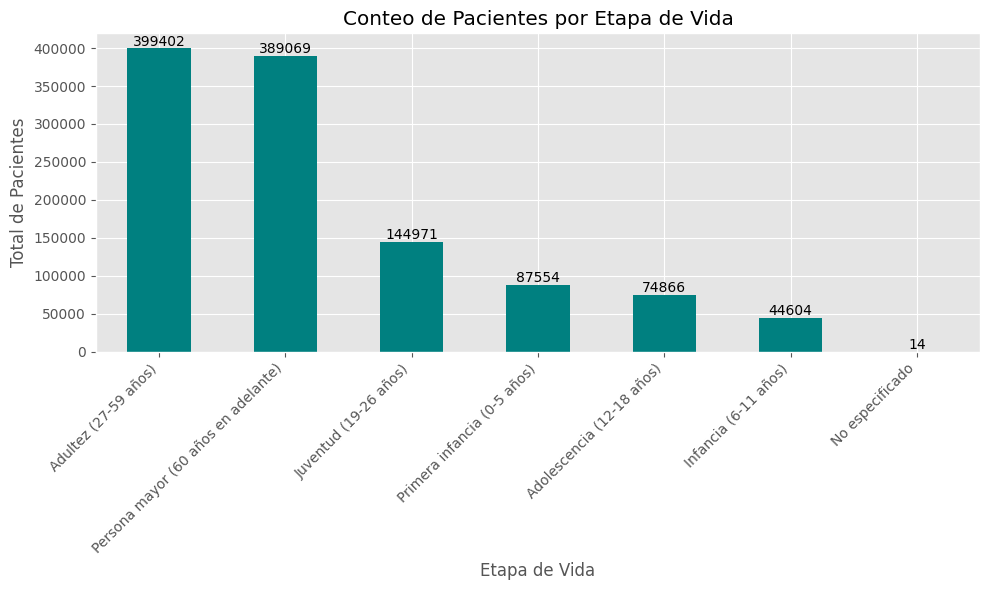

In [ ]:
# 1. Gráfica de barras con el conteo de pacientes por ciclo de vida
plt.figure(figsize=(10, 6))
ax = d['ETAPA_VIDA'].value_counts().plot(kind='bar', color='teal')
plt.title('Conteo de Pacientes por Etapa de Vida')
plt.xlabel('Etapa de Vida')
plt.ylabel('Total de Pacientes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Add the total count values on top of each bar
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.show()

### Grafica distribucción alto costo

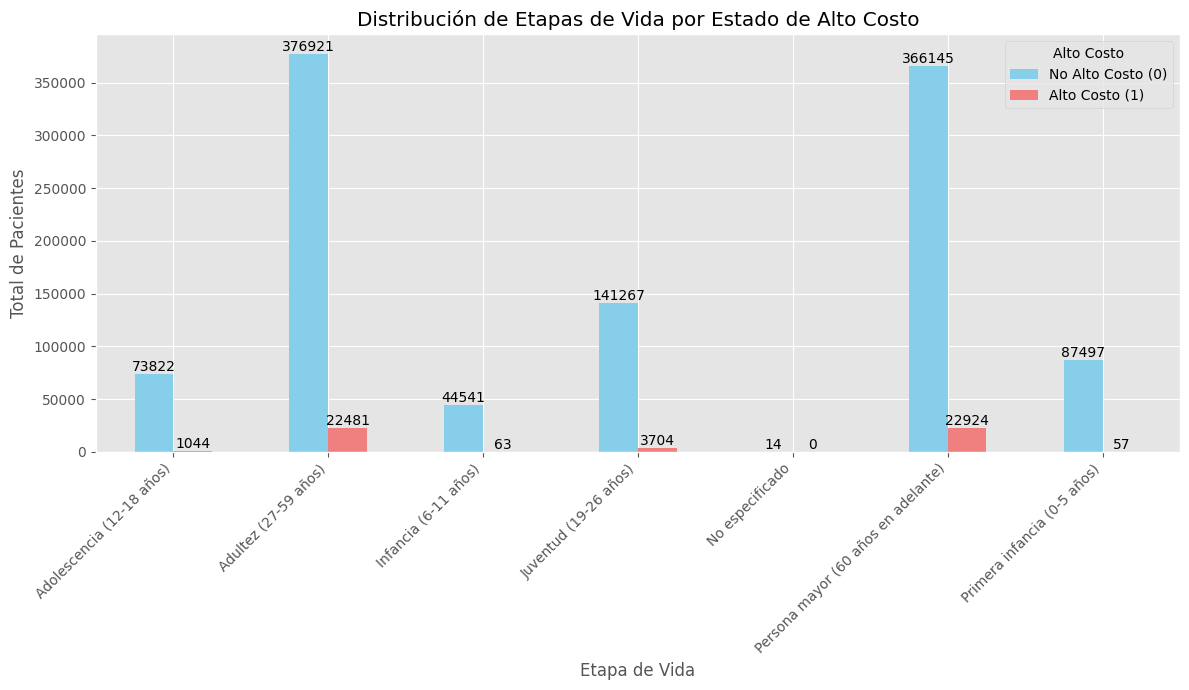

In [ ]:
# Group by 'ETAPA_VIDA' and 'Alto_Costo' and count occurrences
alto_costo_segmentation = d.groupby(['ETAPA_VIDA', 'Alto_Costo']).size().unstack(fill_value=0)

# Plot the results
ax = alto_costo_segmentation.plot(kind='bar', figsize=(12, 7), color=['skyblue', 'lightcoral'])
plt.title('Distribución de Etapas de Vida por Estado de Alto Costo')
plt.xlabel('Etapa de Vida')
plt.ylabel('Total de Pacientes')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Alto Costo', labels=['No Alto Costo (0)', 'Alto Costo (1)'])
plt.tight_layout()

# Add the total count values on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.show()

In [ ]:
#1. ciclo de vida por primer infancia y adultos mayores (ALTO COSTO)
#2. variables objetivo

#-Analizar los factores de riesgo  que identifican las enfermedades de alto costo en la población afiliada a una EPS del régimen subsidiado, con base en los servicios y
# patologías identificadas en prestaciones de servicios pasados para generar una caracterización de las enfermedades y los pacientes.

#-Aplicar técnicas de análisis de datos e Inteligencia de Negocios para identificar patrones en los pacientes de alto costo, permitiendo su segmentación
# según factores de riesgo, necesidades clínicas y costos asociados, con el fin de optimizar la gestión y asignación de recursos.

#-Desarrollar un modelo de categorización que permita segmentar a los pacientes según sus datos históricos de servicios de atención prestada.

#-Desarrollar un sistema de visualización de datos mediante dashboards interactivos que permitan a los tomadores de decisiones acceder a información clave en tiempo real,
# facilitando la identificación de tendencias, alertas tempranas y evaluación de impacto en la atención de pacientes de alto costo.


#pdt redes neuronales

# Analizar los factores de riesgo  que identifican las enfermedades de alto costo en la población afiliada a una EPS del régimen subsidiado, con base en los servicios y patologías identificadas en prestaciones de servicios pasados para generar una caracterización de las enfermedades y los pacientes.

In [ ]:
# Filter the DataFrame to include only high-cost diagnoses
high_cost_df = d[d['Alto_Costo'] == 1].copy()

# Group by 'ETAPA_VIDA' and 'CODIGO DIAGNOSTICO PRINCIPAL' and count occurrences
stage_diagnosis_counts = high_cost_df.groupby(['ETAPA_VIDA', 'CODIGO DIAGNOSTICO PRINCIPAL']).size().sort_values(ascending=False)

# Get the top 10 diagnoses for each life stage
top_10_stage_diagnoses = stage_diagnosis_counts.groupby(level=0).head(10)

# Map the diagnosis codes to their names using the relevant_diagnoses dictionary
# Create a mapping from code to name from the relevant_diagnoses dictionary
code_to_name_map = {}
for keyword, diagnoses in relevant_diagnoses.items():
    for code, name in diagnoses:
        code_to_name_map[code] = name

print("Top 10 Diagnósticos de Alto Costo por Etapa de Vida:")

# Iterate through the top 10 diagnoses, grouping by stage for cleaner output
for stage in top_10_stage_diagnoses.index.get_level_values('ETAPA_VIDA').unique():
    print(f"\n--- Etapa de Vida: {stage} ---")
    stage_data = top_10_stage_diagnoses.loc[stage]
    for code, count in stage_data.items():
        diagnosis_name = code_to_name_map.get(code, "Nombre no encontrado")
        print(f"  - Código CIE10: {code}, Nombre: {diagnosis_name}, Cantidad: {count}")

Top 10 Diagnósticos Principales para Pacientes con Alto Costo por Etapa de Vida:

--- Etapa de Vida: Persona mayor (60 años en adelante) ---
Código: I10X, Nombre: Hipertension esencial (primaria), Cantidad: 5865
Código: Z123, Nombre: Examen de pesquisa especial para tumor de la mama, Cantidad: 4134
Código: Z125, Nombre: Examen de pesquisa especial para tumor de la prostata, Cantidad: 1600
Código: E119, Nombre: Diabetes mellitus no insulinodependiente, sin mencion de complicacion, Cantidad: 1086
Código: N189, Nombre: Enfermedad renal cronica, no especificada, Cantidad: 854
Código: E109, Nombre: Diabetes mellitus insulinodependiente, sin mencion de complicacion, Cantidad: 466
Código: N390, Nombre: Infeccion de vias urinarias, sitio no especificado, Cantidad: 388
Código: I500, Nombre: Insuficiencia cardiaca congestiva, Cantidad: 385
Código: Z031, Nombre: Observacion por sospecha de tumor maligno, Cantidad: 332
Código: C61X, Nombre: Tumor maligno de la prostata, Cantidad: 253

--- Etapa de

# Aplicar técnicas de análisis de datos e Inteligencia de Negocios para identificar patrones en los pacientes de alto costo, permitiendo su segmentación según factores de riesgo, necesidades clínicas y costos asociados, con el fin de optimizar la gestión y asignación de recursos.

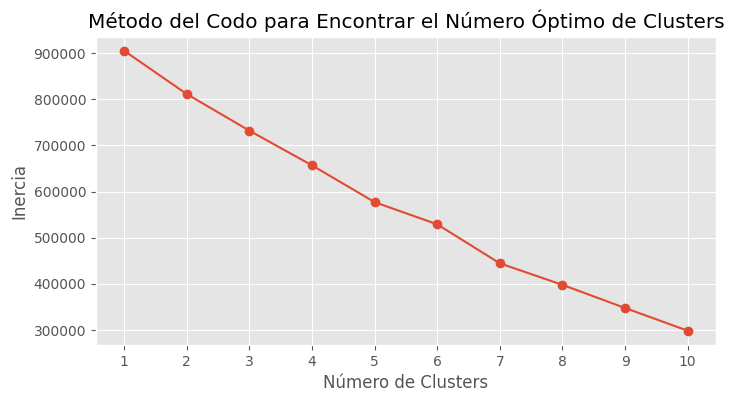

Gráfico del Método del Codo generado. Por favor, examine el gráfico para determinar el número óptimo de clusters y luego ejecute la siguiente celda para aplicar K-Means con el número elegido.


In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Filter the DataFrame for patients with Alto_Costo == 1
alto_costo_df = d[d['Alto_Costo'] == 1].copy()

# Select only numerical features for clustering
# Exclude the target variable itself and potentially other non-relevant numerical IDs
X_clustering = alto_costo_df.select_dtypes(include=np.number).drop(['Alto_Costo', 'UNIDAD FUNCIONAL',
                                                                    'CODIGO BARRIO RESIDENCIA',
                                                                    'CODIGO ESPECIALIDAD'], axis=1, errors='ignore')

# Handle possible missing values (imputation with the mean)
X_clustering = X_clustering.fillna(X_clustering.mean())

# Scale the data before clustering
scaler_clustering = StandardScaler()
X_scaled_clustering = scaler_clustering.fit_transform(X_clustering)

# Determine the optimal number of clusters using the Elbow method
inertia = []
range_n_clusters = range(1, 11) # Test 1 to 10 clusters

for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10) # Added n_init
    kmeans.fit(X_scaled_clustering)
    inertia.append(kmeans.inertia_)

# Plot the Elbow method graph
plt.figure(figsize=(8, 4))
plt.plot(range_n_clusters, inertia, marker='o')
plt.title('Método del Codo para Encontrar el Número Óptimo de Clusters')
plt.xlabel('Número de Clusters')
plt.ylabel('Inercia')
plt.xticks(range_n_clusters)
plt.grid(True)
plt.show()

print("Gráfico del Método del Codo generado. Por favor, examine el gráfico para determinar el número óptimo de clusters y luego ejecute la siguiente celda para aplicar K-Means con el número elegido.")

# Desarrollar un modelo de categorización que permita segmentar a los pacientes según sus datos históricos de servicios de atención prestada (Redes neuronales)

In [ ]:
X_train = np.asarray(X_train).astype('float32')
X_test = np.asarray(X_test).astype('float32')

# Definir el modelo de red neuronal
model = Sequential()
model.add(Dense(128, input_shape=(X_train.shape[1],), activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid')) # Sigmoide para clasificación binaria

# Compilar el modelo
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy']) # Changed loss to binary_crossentropy for binary classification

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,137 (43.50 KB)

 Trainable params: 11,137 (43.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Entrenar el modelo
history = model.fit(X_train, y_train, epochs=15, batch_size=32, validation_split=0.2)

print("Entrenamiento del modelo completado.")

Epoch 1/15
22810/22810 ━━━━━━━━━━━━━━━━━━━━ 53s 2ms/step - accuracy: 0.9549 - loss: 0.1550 - val_accuracy: 0.9559 - val_loss: 0.1510
Epoch 2/15
22810/22810 ━━━━━━━━━━━━━━━━━━━━ 55s 2ms/step - accuracy: 0.9558 - loss: 0.1508 - val_accuracy: 0.9559 - val_loss: 0.1510
Epoch 3/15
22810/22810 ━━━━━━━━━━━━━━━━━━━━ 52s 2ms/step - accuracy: 0.9558 - loss: 0.1499 - val_accuracy: 0.9559 - val_loss: 0.1505
Epoch 4/15
22810/22810 ━━━━━━━━━━━━━━━━━━━━ 55s 2ms/step - accuracy: 0.9556 - loss: 0.1500 - val_accuracy: 0.9559 - val_loss: 0.1517
Epoch 5/15
22810/22810 ━━━━━━━━━━━━━━━━━━━━ 53s 2ms/step - accuracy: 0.9554 - loss: 0.1498 - val_accuracy: 0.9558 - val_loss: 0.1509
Epoch 6/15
22810/22810 ━━━━━━━━━━━━━━━━━━━━ 49s 2ms/step - accuracy: 0.9557 - loss: 0.1493 - val_accuracy: 0.9559 - val_loss: 0.1506
Epoch 7/15
22810/22810 ━━━━━━━━━━━━━━━━━━━━ 48s 2ms/step - accuracy: 0.9557 - loss: 0.1498 - val_accuracy: 0.9557 - val_loss: 0.1510
Epoch 8/15
22810/22810 ━━━━━━━━━━━━━━━━━━━━ 54s 2ms/step - accuracy: 

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Evaluate the model on the test data
loss, accuracy = model.evaluate(X_test, y_test, verbose=0) # Removed _encoded as the target is not one-hot encoded
print(f'Pérdida en prueba: {loss:.4f}')
print(f'Precisión en prueba: {accuracy:.4f}')

# Predict the classes on the test data
y_pred = (model.predict(X_test) > 0.5).astype("int32") # Removed _encoded as the target is not one-hot encoded

# Generate classification report and confusion matrix
print("\nInforme de Clasificación:")
print(classification_report(y_test, y_pred)) # Removed _encoded as the target is not one-hot encoded

print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred)) # Removed _encoded as the target is not one-hot encoded

Pérdida en prueba: 0.1487
Precisión en prueba: 0.9559
7128/7128 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step

Informe de Clasificación:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98    218041
           1       0.00      0.00      0.00     10055

    accuracy                           0.96    228096
   macro avg       0.48      0.50      0.49    228096
weighted avg       0.91      0.96      0.93    228096


Matriz de Confusión:
[[218041      0]
 [ 10055      0]]


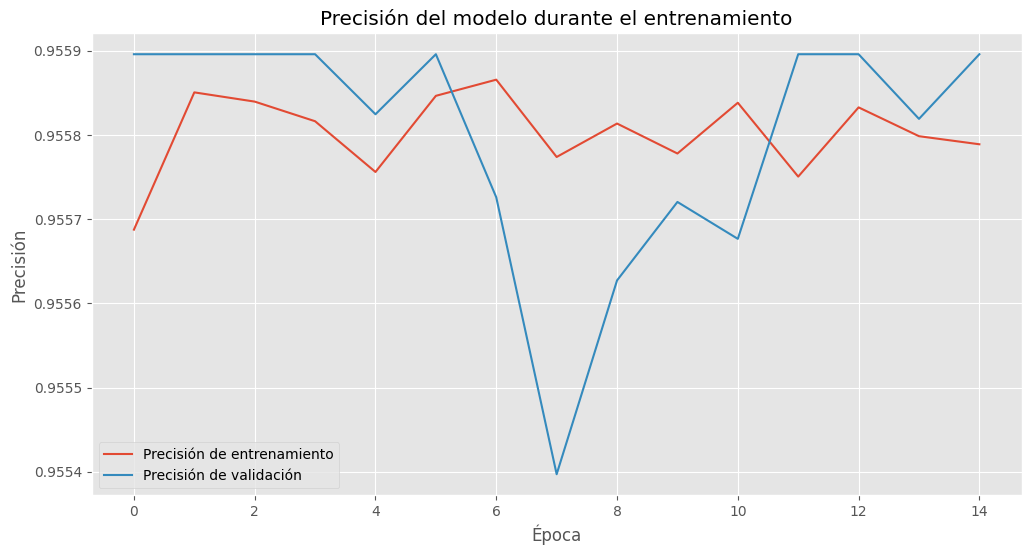

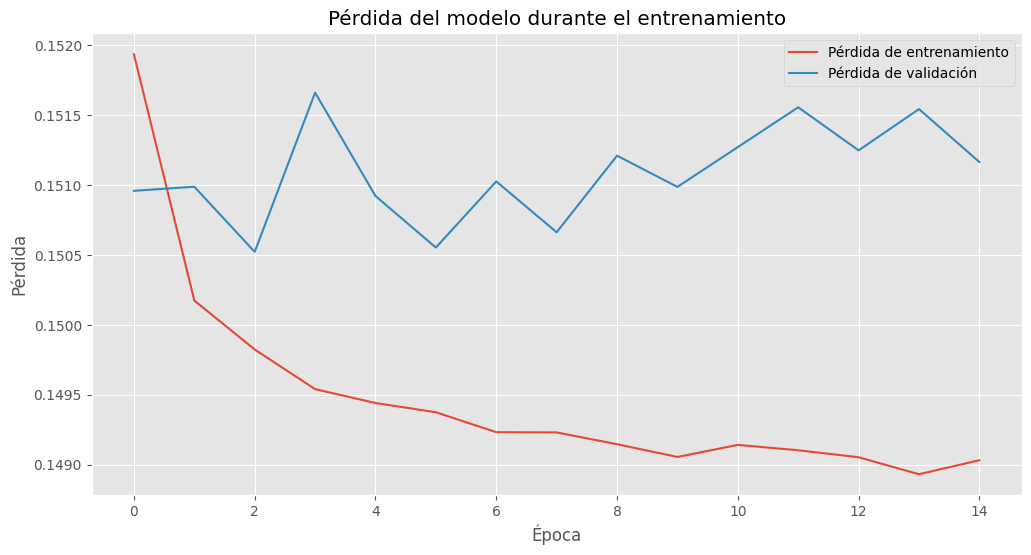

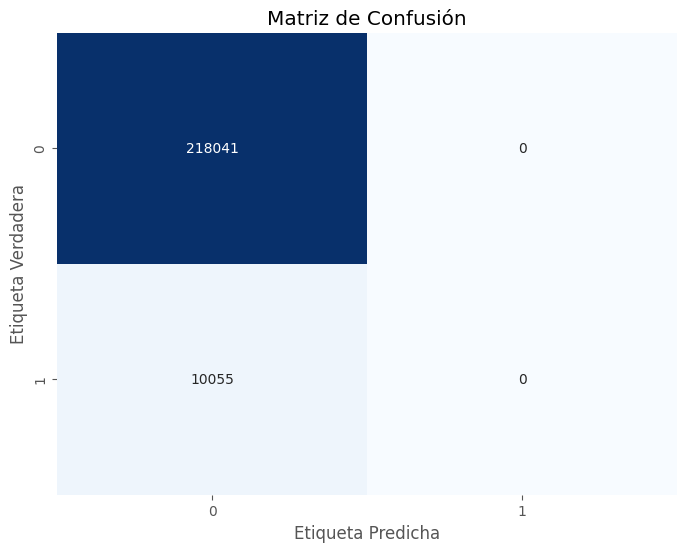

In [ ]:
# Visualización de resultados de la red neuronal

# Gráfico de precisión durante el entrenamiento
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Precisión de entrenamiento')
plt.plot(history.history['val_accuracy'], label='Precisión de validación')
plt.title('Precisión del modelo durante el entrenamiento')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()
plt.show()

# Gráfico de pérdida durante el entrenamiento
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Pérdida de entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida de validación')
plt.title('Pérdida del modelo durante el entrenamiento')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.show()

# Visualización de la matriz de confusión
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred) # Removed _encoded as the target is not one-hot encoded
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusión')
plt.xlabel('Etiqueta Predicha')
plt.ylabel('Etiqueta Verdadera')
plt.show()

# Nota: Para visualizar la clusterización, necesitaría saber qué método de clustering se utilizó (KMeans, Jerárquico, etc.)
# y las características utilizadas para la clusterización. Luego podría generar gráficos como scatter plots de los clusters.
# Para la clasificación, si se realizó una clasificación diferente a la de la red neuronal, también necesitaría los resultados para visualizar.

In [ ]:
# Descargar el DataFrame final como un archivo CSV
d.to_csv('/content/drive/MyDrive/TRABAJO GRADOS/df_final.csv', index=False)
print("DataFrame 'd' descargado como 'df_final.csv'")

DataFrame 'd' descargado como 'df_final.csv'
